# Model 4: BiLSTM with Attention for Swahili News Classification

Prepared by Alain  |  **Model:** `bilstm`

Recurrent models over the same tokenized input as the CNN notebook (Hochreiter and Schmidhuber, 1997; Schuster and Paliwal, 1997), with additive attention (Yang et al., 2016).

**Experiments in this notebook**

| # | Experiment | Question it answers |
|---|------------|---------------------|
| 1 | Plain LSTM (one direction) | Baseline recurrent model |
| 2 | BiLSTM | Does reading in both directions help on long articles? |
| 3 | BiLSTM with attention | Does attention help the model focus on the key words? |
| 4 | Pretrained fastText embeddings | Same question as for the CNN |
| 5 | With and without class weights | Does weighting help the rare classes? |
| 6 | Attention replaced with uniform weights | Does learned attention actually matter? (Wiegreffe and Pinter, 2019) |

**Note on attention weights:** we save them for a few articles for the error analysis, presented as an *illustration*, not as proof of why the model decided (Jain and Wallace, 2019).

## 1. Setup

In [1]:
MEMBER = "Alain"
MODEL_NAME = "bilstm"

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from src import config
from src import data_loading
from src import evaluation
from src import plots
from src.experiment_log import log_experiment
from src.reproducibility import FINAL_RUN_SEEDS, set_seed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 2. Load the data

In [5]:
#fetching the data
train = data_loading.load_train()
validation = data_loading.load_validation()
test = data_loading.load_test()
zindi_test = data_loading.load_zindi_test()

train_ids = data_loading.labels_to_ids(train["category"])
validation_ids = data_loading.labels_to_ids(validation["category"])
test_ids = data_loading.labels_to_ids(test["category"])

print("Labels in order:", config.LABELS)
print("Sizes:",
      len(train), "for train|",
      len(validation), "for validation|",
      len(test), "for test")


Labels in order: ['kitaifa', 'michezo', 'biashara', 'kimataifa', 'burudani']
Sizes: 3603 for train| 772 for validation| 773 for test


## 3. Build and train the model

### 3a. Tokenizer and vocabulary

**Identical to `04_cnn.ipynb`**: both models share the same tokenizer and embeddings, as required. Do not change this block in one notebook without changing it in the other.

In [6]:
import re
from collections import Counter

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
MIN_FREQ = 2


def tokenize(text):
    return re.findall(r"[\w']+", str(text).lower(), flags=re.UNICODE)


def build_vocabulary(texts, min_freq=MIN_FREQ):
    counts = Counter()
    for text in texts:
        counts.update(tokenize(text))
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, n in sorted(counts.items()):
        if n >= min_freq:
            vocab[word] = len(vocab)
    return vocab


def encode(text, vocab, max_len):
    ids = [vocab.get(w, vocab[UNK_TOKEN]) for w in tokenize(text)[:max_len]]
    ids += [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids


vocab = build_vocabulary(train["content"])
print("Vocabulary size:", len(vocab))

Vocabulary size: 28139


### 3b. Experiment settings

- `bidirectional`: False -> plain LSTM (exp 1), True -> BiLSTM (exp 2+)
- `attention`: `"none"` | `"learned"` (exp 3) | `"uniform"` (exp 6, Wiegreffe and Pinter, 2019)
- `embedding`: `"random"` | `"fasttext"` (exp 4)
- `class_weights`: upweight rare classes (exp 5)

In [7]:
settings = {
    "bidirectional": True, # False = plain LSTM (exp 1)
    "attention": "learned", # "none" | "learned" | "uniform" (exp 3 and 6)
    "embedding": "random",  # "random" | "fasttext"           (exp 4)
    "class_weights": False, # upweight rare classes           (exp 5)
    "max_len": 300,
    "embedding_dim": 300,
    "hidden_dim": 128,
    "num_layers": 1,
    "dropout": 0.3,
    "epochs": 30,
    "batch_size": 64,
    "lr": 1e-3,
    "patience": 4, # early stopping
}

### 3c. Embedding matrix (random or pretrained fastText)

In [8]:
FASTTEXT_PATH = "cc.sw.300.vec"


def load_fasttext_vectors(vocab, path, dim):
    vectors = {}
    with open(path, encoding="utf-8", errors="ignore") as f:
        next(f)  # header line
        for line in f:
            parts = line.rstrip().split(" ")
            word, values = parts[0], parts[1:]
            if word in vocab and len(values) == dim:
                vectors[word] = np.asarray(values, dtype=np.float32)
    return vectors


def build_embedding_matrix(vocab, settings):
    dim = settings["embedding_dim"]
    scale = 1.0 / np.sqrt(dim)
    matrix = np.random.uniform(-scale, scale, size=(len(vocab), dim)).astype(np.float32)
    matrix[vocab[PAD_TOKEN]] = 0.0
    if settings["embedding"] == "fasttext":
        pretrained = load_fasttext_vectors(vocab, FASTTEXT_PATH, dim)
        for word, vec in pretrained.items():
            matrix[vocab[word]] = vec
        print(f"fastText coverage: {len(pretrained)}/{len(vocab)} words "
              f"({100 * len(pretrained) / len(vocab):.1f}%)")
    return matrix

### 3d. The BiLSTM with attention

Embedding -> (Bi)LSTM -> pooling:
- `attention = "none"`: mean-pool the hidden states (masked),
- `attention = "learned"`: additive attention; score each hidden state with a small feed-forward layer, softmax over non-padding positions, weighted sum (Yang et al., 2016),
- `attention = "uniform"`: same as mean-pooling, but computed through the attention path so the only difference from `"learned"` is that the weights are not learned (Wiegreffe and Pinter, 2019).

Output layer is linear -> **logits** (softmax only when probabilities are needed). `forward(..., return_attention=True)` also returns the attention weights for the error analysis.

In [9]:
class BiLSTMAttention(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_layers, num_classes,
                 dropout, bidirectional=True, attention="learned"):
        super().__init__()
        self.attention = attention
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix), freeze=False, padding_idx=0
        )
        self.lstm = nn.LSTM(
            embedding_matrix.shape[1], hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.attention_layer = nn.Sequential(nn.Linear(out_dim, out_dim), nn.Tanh(), nn.Linear(out_dim, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(out_dim, num_classes)

    def forward(self, x, return_attention=False):
        mask = x != 0     # (batch, seq_len) True for real tokens
        hidden, _ = self.lstm(self.embedding(x))   # (batch, seq_len, out_dim)

        if self.attention == "learned":
            scores = self.attention_layer(hidden).squeeze(-1)  # (batch, seq_len)
            scores = scores.masked_fill(~mask, -1e9)
            weights = torch.softmax(scores, dim=1)
            pooled = torch.bmm(weights.unsqueeze(1), hidden).squeeze(1)
        else:  # "none" (mean pool) or "uniform" (mean pool via attention path)
            lengths = mask.sum(dim=1, keepdim=True).clamp(min=1)
            weights = mask.float() / lengths
            pooled = torch.bmm(weights.unsqueeze(1), hidden).squeeze(1)

        logits = self.fc(self.dropout(pooled))
        if return_attention:
            return logits, weights
        return logits


def build_model(embedding_matrix):
    return BiLSTMAttention(
        embedding_matrix=embedding_matrix,
        hidden_dim=settings["hidden_dim"],
        num_layers=settings["num_layers"],
        num_classes=len(config.LABELS),
        dropout=settings["dropout"],
        bidirectional=settings["bidirectional"],
        attention=settings["attention"],
    ).to(device)

### 3e. Training loop

Same protocol as the CNN notebook: early stopping on validation loss, per-epoch `train_loss` / `validation_loss` / `validation_macro_f1`, optional class weights, returns validation **logits** for temperature scaling.

In [10]:
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight


class NewsDataset(Dataset):
    def __init__(self, texts, targets=None):
        self.texts = list(texts)
        self.targets = None if targets is None else np.asarray(targets)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        x = torch.tensor(encode(self.texts[i], vocab, settings["max_len"]), dtype=torch.long)
        if self.targets is None:
            return x
        return x, torch.tensor(self.targets[i], dtype=torch.long)


@torch.no_grad()
def predict_logits(model, texts):
    model.eval()
    loader = DataLoader(NewsDataset(texts), batch_size=256)
    return torch.cat([model(x.to(device)) for x in loader]).cpu()


def train_model(seed=config.RANDOM_SEED):
    set_seed(seed)
    embedding_matrix = build_embedding_matrix(vocab, settings)
    model = build_model(embedding_matrix)
    optimizer = torch.optim.Adam(model.parameters(), lr=settings["lr"])

    if settings["class_weights"]:
        weights = compute_class_weight(
            "balanced", classes=np.arange(len(config.LABELS)), y=train_ids
        )
        criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=device))
    else:
        criterion = nn.CrossEntropyLoss()

    train_loader = DataLoader(
        NewsDataset(train["content"], train_ids), batch_size=settings["batch_size"], shuffle=True
    )
    val_x = NewsDataset(validation["content"])
    val_inputs = torch.stack([val_x[i] for i in range(len(val_x))]).to(device)
    val_targets = torch.tensor(validation_ids, device=device)

    history = {"train_loss": [], "validation_loss": [], "validation_macro_f1": []}
    best_state, best_val_loss, epochs_without_improvement = None, float("inf"), 0

    for epoch in range(1, settings["epochs"] + 1):
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)  # LSTMs can explode
            optimizer.step()
            total_loss += loss.item() * len(y)

        model.eval()
        with torch.no_grad():
            val_logits = model(val_inputs)
            val_loss = criterion(val_logits, val_targets).item()
            val_macro_f1 = f1_score(validation_ids, val_logits.argmax(1).cpu(),
                                    average="macro", zero_division=0)

        history["train_loss"].append(total_loss / len(train))
        history["validation_loss"].append(val_loss)
        history["validation_macro_f1"].append(val_macro_f1)
        print(f"epoch {epoch:02d} | train_loss {history['train_loss'][-1]:.4f} "
              f"| val_loss {val_loss:.4f} | val_macro_f1 {val_macro_f1:.4f}")

        if val_loss < best_val_loss:
            best_val_loss, best_state = val_loss, {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= settings["patience"]:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    validation_logits = predict_logits(model, validation["content"]).numpy()
    return model, history, validation_logits


model, history, validation_logits = train_model()

Random seed set to 42
epoch 01 | train_loss 1.0727 | val_loss 0.6402 | val_macro_f1 0.3837
epoch 02 | train_loss 0.5451 | val_loss 0.5738 | val_macro_f1 0.4342
epoch 03 | train_loss 0.3604 | val_loss 0.3935 | val_macro_f1 0.5304
epoch 04 | train_loss 0.2516 | val_loss 0.4802 | val_macro_f1 0.4880
epoch 05 | train_loss 0.2152 | val_loss 0.5384 | val_macro_f1 0.4939
epoch 06 | train_loss 0.1318 | val_loss 0.4808 | val_macro_f1 0.5117
epoch 07 | train_loss 0.0875 | val_loss 0.5237 | val_macro_f1 0.5578
Early stopping at epoch 7


## 4. Evaluate on the validation set

Run this section after **every** experiment. Change `experiment_name` and `notes` each time.

In [11]:
experiment_name = "bilstm_attention"

notes = "BiLSTM with learned attention, random embeddings, no class weights"

validation_probabilities = torch.softmax(torch.tensor(validation_logits), dim=1).numpy()

validation_scores = evaluation.compute_scores(validation_ids, validation_probabilities)
evaluation.print_classification_report(validation_ids, validation_probabilities)
log_experiment(MEMBER, MODEL_NAME, experiment_name, "validation", settings, validation_scores, notes)

validation_scores

              precision    recall  f1-score   support

     kitaifa       0.87      0.83      0.85       300
     michezo       0.93      0.98      0.95       258
    biashara       0.83      0.87      0.85       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         2

    accuracy                           0.88       772
   macro avg       0.53      0.54      0.53       772
weighted avg       0.87      0.88      0.87       772

Logged experiment 'bilstm_attention' to /content/nlp_language_technologies/results/experiment_logs/bilstm.csv


{'accuracy': 0.8795,
 'log_loss': 0.3935,
 'macro_f1': 0.5304,
 'weighted_f1': 0.8731,
 'f1_kitaifa': 0.8479,
 'f1_michezo': 0.9547,
 'f1_biashara': 0.8496,
 'f1_kimataifa': 0.0,
 'f1_burudani': 0.0}

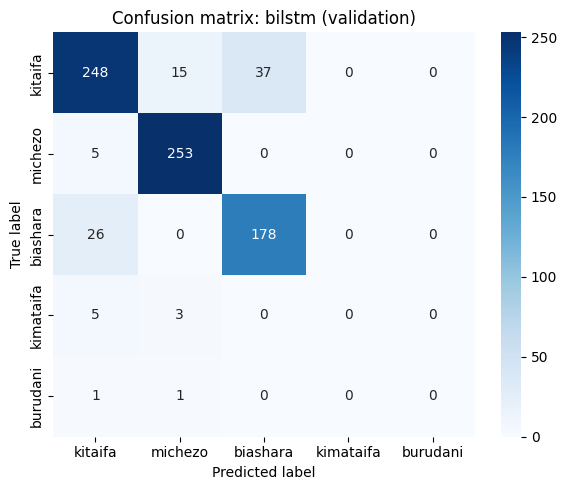

In [12]:
plots.plot_confusion_matrix(validation_ids, validation_probabilities, MODEL_NAME, "validation")

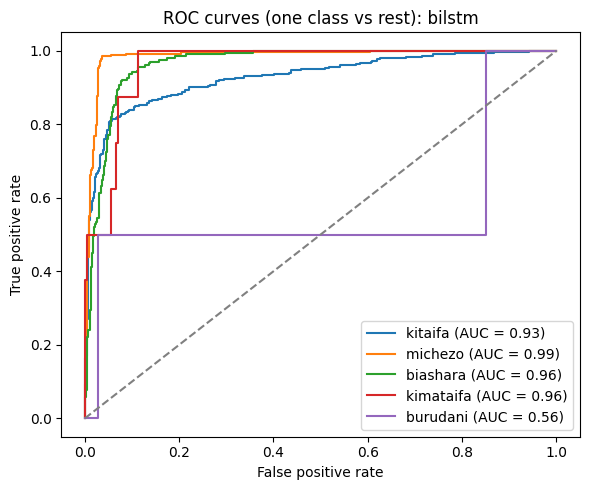

In [13]:
plots.plot_roc_curves(validation_ids, validation_probabilities, MODEL_NAME, "validation")

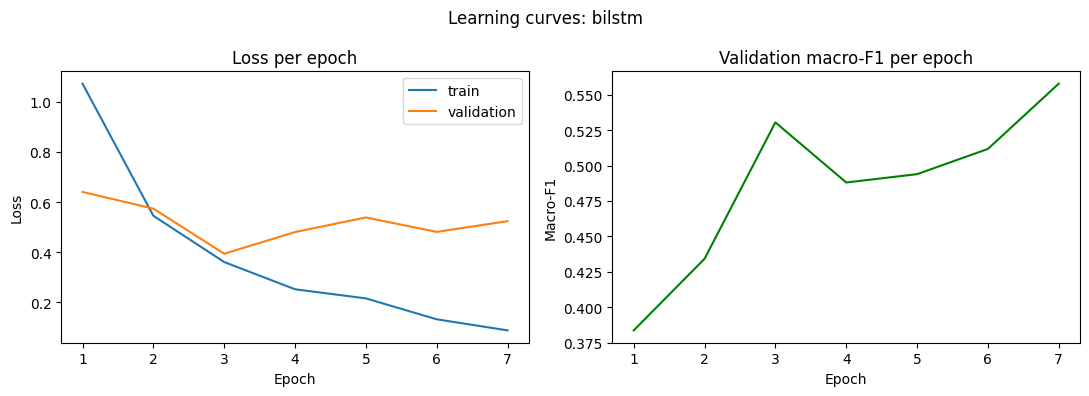

In [14]:
plots.plot_learning_curves(history, MODEL_NAME)

### 4c. Calibration (temperature scaling)

Same as the CNN notebook: fit one temperature on the validation logits (Guo et al., 2017), and log scores before and after.

In [15]:
from src import calibration

temperature = calibration.find_best_temperature(validation_logits, validation_ids)
print("Best temperature:", temperature)

calibrated_probabilities = calibration.softmax(validation_logits, temperature)
calibrated_scores = evaluation.compute_scores(validation_ids, calibrated_probabilities)

log_experiment(MEMBER, MODEL_NAME, experiment_name + "_calibrated", "validation",
               {**settings, "temperature": temperature}, calibrated_scores,
               "Same model after temperature scaling")
calibrated_scores

Best temperature: 1.05 (validation log loss 0.3924)
Best temperature: 1.0500000000000005
Logged experiment 'bilstm_attention_calibrated' to /content/nlp_language_technologies/results/experiment_logs/bilstm.csv


{'accuracy': 0.8795,
 'log_loss': 0.3924,
 'macro_f1': 0.5304,
 'weighted_f1': 0.8731,
 'f1_kitaifa': 0.8479,
 'f1_michezo': 0.9547,
 'f1_biashara': 0.8496,
 'f1_kimataifa': 0.0,
 'f1_burudani': 0.0}

### 4d. Attention weights for the error analysis

Save attention weights for a few articles (used by Vestine's error analysis). These are an **illustration**, not an explanation of the model's decision (Jain and Wallace, 2019).

In [16]:
@torch.no_grad()
def attention_for_text(model, text, top_k=15):
    model.eval()
    ids = torch.tensor([encode(text, vocab, settings["max_len"])], dtype=torch.long, device=device)
    logits, weights = model(ids, return_attention=True)
    tokens = tokenize(text)[: settings["max_len"]]
    w = weights[0, : len(tokens)].cpu().numpy()
    order = np.argsort(w)[::-1][:top_k]
    return pd.DataFrame({
        "token": [tokens[i] for i in order],
        "attention_weight": w[order],
        "predicted": config.LABELS[int(logits.argmax(1).item())],
    })


attention_examples = []
for i in range(5):  # a few validation articles
    row = attention_for_text(model, validation["content"].iloc[i])
    row["true_label"] = validation["category"].iloc[i]
    attention_examples.append(row)

attention_examples = pd.concat(attention_examples)
out_path = Path("results") / "figures" / MODEL_NAME / "attention_examples.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
attention_examples.to_csv(out_path, index=False)
print("Saved to", out_path)
attention_examples.head(15)

Saved to results/figures/bilstm/attention_examples.csv


,token,attention_weight,predicted,true_label
0,aishi,0.099021,michezo,michezo
1,beki,0.093468,michezo,michezo
2,kipa,0.083970,michezo,michezo
3,mabao,0.078898,michezo,michezo
4,stars,0.066026,michezo,michezo
5,mechi,0.064300,michezo,michezo
6,mechi,0.051763,michezo,michezo
7,ilifungwa,0.043316,michezo,michezo
8,mazoezi,0.039356,michezo,michezo
9,michuano,0.029692,michezo,michezo


## 5. Final evaluation on the test set

Random seed set to 42
epoch 01 | train_loss 1.0727 | val_loss 0.6402 | val_macro_f1 0.3837
epoch 02 | train_loss 0.5451 | val_loss 0.5738 | val_macro_f1 0.4342
epoch 03 | train_loss 0.3604 | val_loss 0.3935 | val_macro_f1 0.5304
epoch 04 | train_loss 0.2516 | val_loss 0.4802 | val_macro_f1 0.4880
epoch 05 | train_loss 0.2152 | val_loss 0.5384 | val_macro_f1 0.4939
epoch 06 | train_loss 0.1318 | val_loss 0.4808 | val_macro_f1 0.5117
epoch 07 | train_loss 0.0875 | val_loss 0.5237 | val_macro_f1 0.5578
Early stopping at epoch 7
Best temperature: 1.05 (validation log loss 0.3924)
              precision    recall  f1-score   support

     kitaifa       0.86      0.82      0.84       300
     michezo       0.94      0.96      0.95       258
    biashara       0.80      0.86      0.83       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         3

    accuracy                           0.87       773
   macro avg       0.52      0.53    

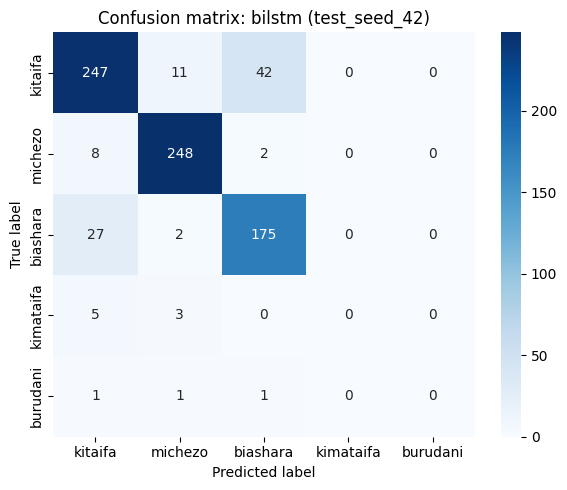

Random seed set to 7
epoch 01 | train_loss 1.0830 | val_loss 0.7034 | val_macro_f1 0.3222
epoch 02 | train_loss 0.5907 | val_loss 0.5094 | val_macro_f1 0.4763
epoch 03 | train_loss 0.3624 | val_loss 0.3957 | val_macro_f1 0.5156
epoch 04 | train_loss 0.2179 | val_loss 0.3903 | val_macro_f1 0.5150
epoch 05 | train_loss 0.1366 | val_loss 0.5210 | val_macro_f1 0.5098
epoch 06 | train_loss 0.1009 | val_loss 0.5774 | val_macro_f1 0.5097
epoch 07 | train_loss 0.0799 | val_loss 0.6155 | val_macro_f1 0.5047
epoch 08 | train_loss 0.0588 | val_loss 0.6417 | val_macro_f1 0.5098
Early stopping at epoch 8
Best temperature: 1.15 (validation log loss 0.3836)
              precision    recall  f1-score   support

     kitaifa       0.78      0.88      0.83       300
     michezo       0.95      0.93      0.94       258
    biashara       0.85      0.75      0.80       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         3

    accuracy           

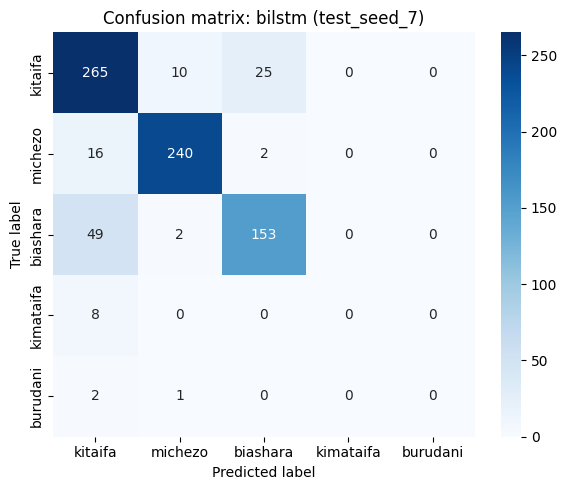

Random seed set to 2026
epoch 01 | train_loss 1.1035 | val_loss 0.6863 | val_macro_f1 0.3150
epoch 02 | train_loss 0.6162 | val_loss 0.4981 | val_macro_f1 0.5098
epoch 03 | train_loss 0.3630 | val_loss 0.3889 | val_macro_f1 0.5265
epoch 04 | train_loss 0.2238 | val_loss 0.4342 | val_macro_f1 0.5085
epoch 05 | train_loss 0.1713 | val_loss 0.4485 | val_macro_f1 0.5104
epoch 06 | train_loss 0.1003 | val_loss 0.4515 | val_macro_f1 0.5237
epoch 07 | train_loss 0.0784 | val_loss 0.7102 | val_macro_f1 0.4867
Early stopping at epoch 7
Best temperature: 1.10 (validation log loss 0.3871)
              precision    recall  f1-score   support

     kitaifa       0.85      0.84      0.85       300
     michezo       0.95      0.94      0.94       258
    biashara       0.82      0.90      0.86       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         3

    accuracy                           0.88       773
   macro avg       0.52      0.54  

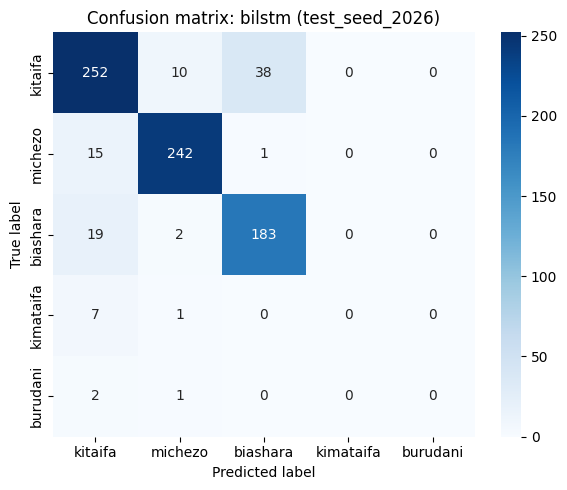

In [17]:
for seed in FINAL_RUN_SEEDS:
    final_model, final_history, val_logits = train_model(seed=seed)

    temperature = calibration.find_best_temperature(val_logits, validation_ids)
    test_logits = predict_logits(final_model, test["content"]).numpy()
    test_probabilities = calibration.softmax(test_logits, temperature)

    test_scores = evaluation.compute_scores(test_ids, test_probabilities)
    evaluation.print_classification_report(test_ids, test_probabilities)
    log_experiment(MEMBER, MODEL_NAME, f"final_seed_{seed}", "test",
                   {**settings, "temperature": temperature}, test_scores,
                   "Final model on the test set")

    plots.plot_confusion_matrix(test_ids, test_probabilities, MODEL_NAME, f"test_seed_{seed}")


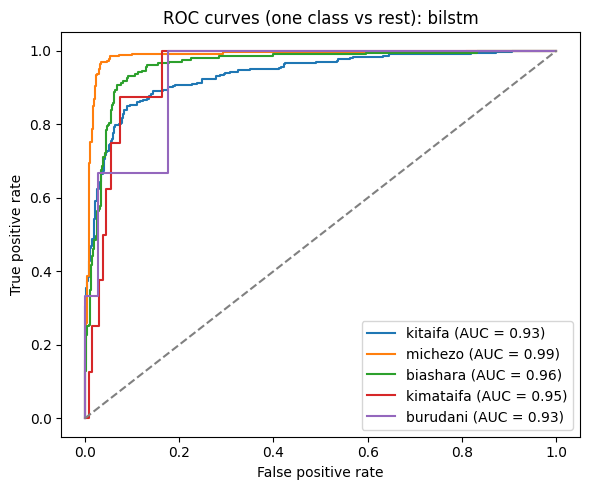

In [18]:
plots.plot_roc_curves(test_ids, test_probabilities, MODEL_NAME, "test")

In [19]:
evaluation.save_misclassified_examples(test, test_ids, test_probabilities, MODEL_NAME)

Saved 96 misclassified examples to /content/nlp_language_technologies/results/misclassified/bilstm.csv


In [20]:
# attention weights for a few misclassified test articles, for the error analysis
misclassified_rows = []
for i in np.where(np.asarray(test_ids) != test_probabilities.argmax(1))[0][:5]:
    row = attention_for_text(final_model, test["content"].iloc[i])
    row["true_label"] = test["category"].iloc[i]
    misclassified_rows.append(row)

if misclassified_rows:
    out_path = Path("results") / "figures" / MODEL_NAME / "attention_misclassified_test.csv"
    pd.concat(misclassified_rows).to_csv(out_path, index=False)
    print("Saved to", out_path)

Saved to results/figures/bilstm/attention_misclassified_test.csv


In [21]:
zindi_logits = predict_logits(final_model, zindi_test["content"]).numpy()
zindi_probabilities = calibration.softmax(zindi_logits, temperature)

evaluation.save_zindi_submission(zindi_test, zindi_probabilities, MODEL_NAME)

Saved Zindi submission to /content/nlp_language_technologies/results/submissions/bilstm.csv
